In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"

In [4]:
params = {
    "settlementDateFrom": "2024-01-01",
    "settlementDateTo": "2024-01-31",
    "fuelType": "WIND",
    "format": "json"
}

In [5]:
import requests

In [6]:
response = requests.get(url, params=params)
data = response.json()

In [7]:
df_actual = pd.DataFrame(data)

In [8]:
df_actual

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-02-01T00:00:00Z,2024-01-31T23:30:00Z,2024-01-31,48,WIND,14355
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31T23:00:00Z,2024-01-31,47,WIND,14595
2,FUELHH,2024-01-31T23:00:00Z,2024-01-31T22:30:00Z,2024-01-31,46,WIND,14908
3,FUELHH,2024-01-31T22:30:00Z,2024-01-31T22:00:00Z,2024-01-31,45,WIND,15490
4,FUELHH,2024-01-31T22:00:00Z,2024-01-31T21:30:00Z,2024-01-31,44,WIND,15719
...,...,...,...,...,...,...,...
1483,FUELHH,2024-01-01T02:30:00Z,2024-01-01T02:00:00Z,2024-01-01,5,WIND,11234
1484,FUELHH,2024-01-01T02:00:00Z,2024-01-01T01:30:00Z,2024-01-01,4,WIND,11223
1485,FUELHH,2024-01-01T01:30:00Z,2024-01-01T01:00:00Z,2024-01-01,3,WIND,11218
1486,FUELHH,2024-01-01T01:00:00Z,2024-01-01T00:30:00Z,2024-01-01,2,WIND,10845


In [11]:
url2 = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"

In [12]:
params2 = {
    "publishDateTimeFrom": "2024-01-01T00:00:00Z",
    "publishDateTimeTo": "2024-01-31T23:59:59Z",
    "format": "json"
}

In [13]:
response2 = requests.get(url2, params=params2)

In [14]:
df_forecast = pd.DataFrame(response2.json())

In [15]:
df_forecast

,dataset,publishTime,startTime,generation
0,WINDFOR,2024-01-31T22:30:00Z,2024-01-31T21:00:00Z,17543
1,WINDFOR,2024-01-31T22:30:00Z,2024-01-31T22:00:00Z,17315
2,WINDFOR,2024-01-31T22:30:00Z,2024-01-31T23:00:00Z,16909
3,WINDFOR,2024-01-31T22:30:00Z,2024-02-01T00:00:00Z,16341
4,WINDFOR,2024-01-31T22:30:00Z,2024-02-01T01:00:00Z,15630
...,...,...,...,...
12147,WINDFOR,2024-01-01T02:30:00Z,2024-01-03T17:00:00Z,10479
12148,WINDFOR,2024-01-01T02:30:00Z,2024-01-03T18:00:00Z,10470
12149,WINDFOR,2024-01-01T02:30:00Z,2024-01-03T19:00:00Z,10520
12150,WINDFOR,2024-01-01T02:30:00Z,2024-01-03T20:00:00Z,10573


In [16]:
df_forecast['startTime'] = pd.to_datetime(df_forecast['startTime'])
df_forecast['publishTime'] = pd.to_datetime(df_forecast['publishTime'])

In [17]:
df_forecast['startTime']

0       2024-01-31 21:00:00+00:00
1       2024-01-31 22:00:00+00:00
2       2024-01-31 23:00:00+00:00
3       2024-02-01 00:00:00+00:00
4       2024-02-01 01:00:00+00:00
                   ...           
12147   2024-01-03 17:00:00+00:00
12148   2024-01-03 18:00:00+00:00
12149   2024-01-03 19:00:00+00:00
12150   2024-01-03 20:00:00+00:00
12151   2024-01-03 21:00:00+00:00
Name: startTime, Length: 12152, dtype: datetime64[ns, UTC]

In [18]:
df_forecast['publishTime']

0       2024-01-31 22:30:00+00:00
1       2024-01-31 22:30:00+00:00
2       2024-01-31 22:30:00+00:00
3       2024-01-31 22:30:00+00:00
4       2024-01-31 22:30:00+00:00
                   ...           
12147   2024-01-01 02:30:00+00:00
12148   2024-01-01 02:30:00+00:00
12149   2024-01-01 02:30:00+00:00
12150   2024-01-01 02:30:00+00:00
12151   2024-01-01 02:30:00+00:00
Name: publishTime, Length: 12152, dtype: datetime64[ns, UTC]

In [19]:
df_forecast['horizon_hours'] = (df_forecast['startTime'] - df_forecast['publishTime']).dt.total_seconds() / 3600

In [20]:
df_forecast['horizon_hours']

0        -1.5
1        -0.5
2         0.5
3         1.5
4         2.5
         ... 
12147    62.5
12148    63.5
12149    64.5
12150    65.5
12151    66.5
Name: horizon_hours, Length: 12152, dtype: float64

In [21]:
df_forecast = df_forecast[(df_forecast['horizon_hours'] >= 0) & (df_forecast['horizon_hours'] <= 48)]

In [28]:
type(df_actual['startTime'])

pandas.core.series.Series

In [29]:
type(df_forecast['startTime'])

pandas.core.series.Series

In [31]:
df_actual['startTime'] = pd.to_datetime(df_actual['startTime'], utc=True)

In [32]:
df = pd.merge(df_actual, df_forecast, on='startTime', how='inner')

In [33]:
df

,dataset_x,publishTime_x,startTime,settlementDate,settlementPeriod,fuelType,generation_x,dataset_y,publishTime_y,generation_y,horizon_hours
0,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 22:30:00+00:00,16909,0.5
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 18:30:00+00:00,17275,4.5
2,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 15:30:00+00:00,17263,7.5
3,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 11:30:00+00:00,17176,11.5
4,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 09:30:00+00:00,17183,13.5
...,...,...,...,...,...,...,...,...,...,...,...
9195,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 11:30:00+00:00,10072,9.5
9196,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 09:30:00+00:00,10065,11.5
9197,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 07:30:00+00:00,10065,13.5
9198,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 04:30:00+00:00,9432,16.5


In [36]:
df['error'] = df['generation_x'] - df['generation_y']

In [37]:
df

,dataset_x,publishTime_x,startTime,settlementDate,settlementPeriod,fuelType,generation_x,dataset_y,publishTime_y,generation_y,horizon_hours,error
0,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 22:30:00+00:00,16909,0.5,-2314
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 18:30:00+00:00,17275,4.5,-2680
2,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 15:30:00+00:00,17263,7.5,-2668
3,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 11:30:00+00:00,17176,11.5,-2581
4,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 09:30:00+00:00,17183,13.5,-2588
...,...,...,...,...,...,...,...,...,...,...,...,...
9195,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 11:30:00+00:00,10072,9.5,3881
9196,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 09:30:00+00:00,10065,11.5,3888
9197,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 07:30:00+00:00,10065,13.5,3888
9198,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 04:30:00+00:00,9432,16.5,4521


In [38]:
df['errorAbs'] = df['error'].abs()

In [39]:
df

,dataset_x,publishTime_x,startTime,settlementDate,settlementPeriod,fuelType,generation_x,dataset_y,publishTime_y,generation_y,horizon_hours,error,errorAbs
0,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 22:30:00+00:00,16909,0.5,-2314,2314
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 18:30:00+00:00,17275,4.5,-2680,2680
2,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 15:30:00+00:00,17263,7.5,-2668,2668
3,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 11:30:00+00:00,17176,11.5,-2581,2581
4,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 09:30:00+00:00,17183,13.5,-2588,2588
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9195,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 11:30:00+00:00,10072,9.5,3881,3881
9196,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 09:30:00+00:00,10065,11.5,3888,3888
9197,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 07:30:00+00:00,10065,13.5,3888,3888
9198,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 04:30:00+00:00,9432,16.5,4521,4521


In [40]:
print(df['errorAbs'].mean())

2071.510543478261


In [41]:
print(df['errorAbs'].median())

1806.5


In [42]:
print(df['errorAbs'].quantile(0.99))

7189.410000000009


In [43]:
import matplotlib.pyplot as plt

In [44]:
df['horizon_rounded'] = df['horizon_hours'].round(0)

In [55]:
horizon_error = df.groupby('horizon_rounded')['errorAbs'].mean()

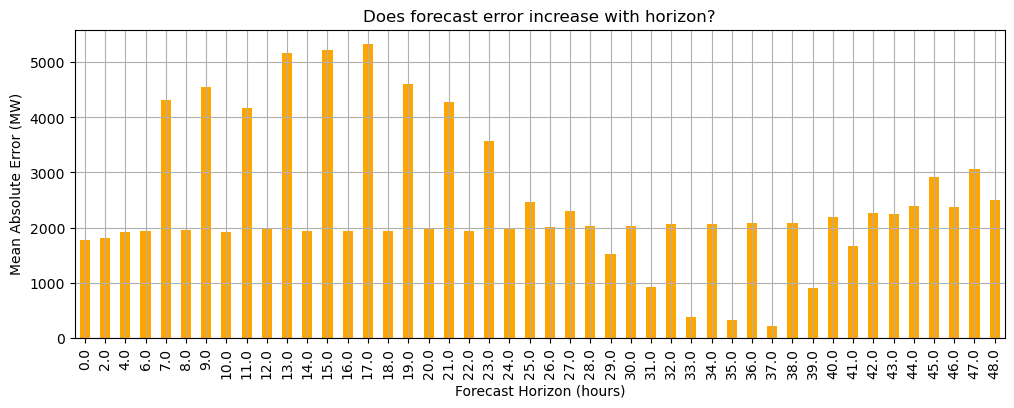

In [62]:
horizon_error.plot(kind='bar', figsize=(12,4), color='orange')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('Mean Absolute Error (MW)')
plt.title('Does forecast error increase with horizon?')
plt.grid(True)
plt.show()

In [49]:
df['hour'] = df['startTime'].dt.hour

In [60]:
hourly_error = df.groupby('hour')['errorAbs'].mean()

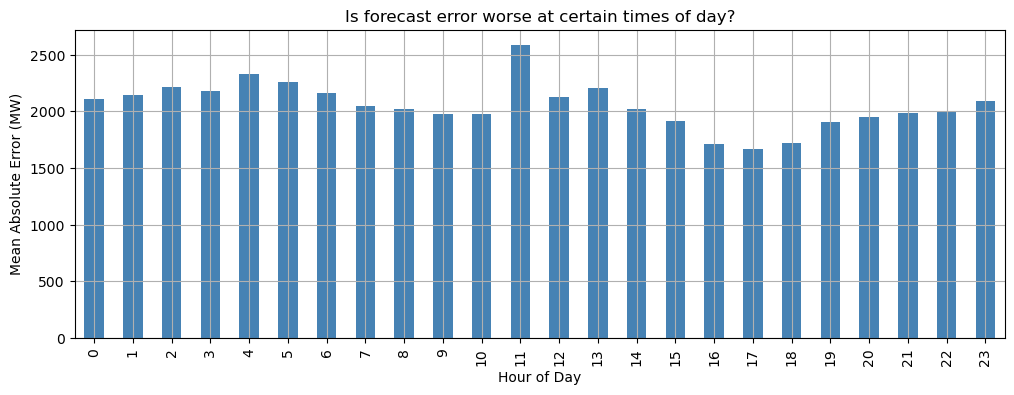

In [61]:
hourly_error.plot(kind='bar', figsize=(12,4), color='steelblue')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Absolute Error (MW)')
plt.title('Is forecast error worse at certain times of day?')
plt.grid(True)
plt.show()

In [57]:
df

,dataset_x,publishTime_x,startTime,settlementDate,settlementPeriod,fuelType,generation_x,dataset_y,publishTime_y,generation_y,horizon_hours,error,errorAbs,horizon_rounded,hour
0,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 22:30:00+00:00,16909,0.5,-2314,2314,0.0,23
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 18:30:00+00:00,17275,4.5,-2680,2680,4.0,23
2,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 15:30:00+00:00,17263,7.5,-2668,2668,8.0,23
3,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 11:30:00+00:00,17176,11.5,-2581,2581,12.0,23
4,FUELHH,2024-01-31T23:30:00Z,2024-01-31 23:00:00+00:00,2024-01-31,47,WIND,14595,WINDFOR,2024-01-31 09:30:00+00:00,17183,13.5,-2588,2588,14.0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9195,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 11:30:00+00:00,10072,9.5,3881,3881,10.0,21
9196,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 09:30:00+00:00,10065,11.5,3888,3888,12.0,21
9197,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 07:30:00+00:00,10065,13.5,3888,3888,14.0,21
9198,FUELHH,2024-01-01T21:30:00Z,2024-01-01 21:00:00+00:00,2024-01-01,43,WIND,13953,WINDFOR,2024-01-01 04:30:00+00:00,9432,16.5,4521,4521,16.0,21
